# Project Description - Tools classification and localization using YOLO
**Introduction** <br>
This is a project of tools classification/localization. There are 6 different classes:
- Cutter
- Tongs
- Screws_box
- Screwdriver
- Drill_bit
- Allen_keys

**Outline** <br>
This project will have the presentation outlined as follows,
1. Dataset visualization
2. Model training and validation
3. Model testing
4. Results evaluation
5. Model prediction

# Objetive: use YOLO in the lab07 - "SingleDetectionTool"

- Any model of Yolo (short, medium,...) can be used
- Inference in all test images
- Compare with Lab07 (MobileNet and ViT)

## Imports

In [ ]:
# Import necessary libraries

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
import random
from matplotlib.patches import Rectangle
from matplotlib import pyplot
from lxml import etree
from sklearn.model_selection import train_test_split #function to split a dataset
import shutil #library with function to copy files between folders
from sklearn.preprocessing import LabelBinarizer

# Enable Matplotlib backend for displaying static images
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH = '/content/sample_data/Data/'
DRIVE_PATH = '/content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/03a - SingleDetection-Tools/YOLO/'

In [ ]:
!unzip -q '/content/drive/MyDrive/Colab_Notebooks/Computer Vision course/DL/03a - SingleDetection-Tools/YOLO/Data/Label_studio.zip' -d '/content/sample_data/Data'

In [ ]:
# Inspect Data, there are 100 images for each of the 6 classes, for a total of 600.

images_names = os.listdir(PATH+'Label_studio/images')
print('Total images: ', len(images_names))
xml_names = os.listdir(PATH+'Label_studio/labels')
print('Total annotations: ', len(xml_names))

Total images:  600
Total annotations:  600


## Divide data into train, valid and test folders

In [ ]:
def get_class_from_YOLO(path):

    with open(path, 'r') as file:
        return file.read()[0]

get_class_from_YOLO(r'/content/sample_data/Data/Label_studio/labels/00451535-drill_bit28.txt')

'2'

In [ ]:
# Create folders to Data and Models
try:
    os.makedirs(PATH+'Data', exist_ok=True)
    os.makedirs(PATH+'Data/Train', exist_ok=True)
    os.makedirs(PATH+'Data/Train/images', exist_ok=True)
    os.makedirs(PATH+'Data/Train/labels', exist_ok=True)
    os.makedirs(PATH+'Data/Valid', exist_ok=True)
    os.makedirs(PATH+'Data/Valid/images', exist_ok=True)
    os.makedirs(PATH+'Data/Valid/labels', exist_ok=True)
    os.makedirs(PATH+'Data/Test', exist_ok=True)
    os.makedirs(PATH+'Data/Test/images', exist_ok=True)
    os.makedirs(PATH+'Data/Test/labels', exist_ok=True)
except:
    print('Error creating folders')

# Define path to folders
path_images = PATH+'Label_studio/images'
path_xml = PATH+'Label_studio/labels'
path_train = PATH+'Data/Train'
path_valid = PATH+'Data/Valid'
path_test = PATH+'Data/Test'

# Get the class of each image
elements = []

for item in xml_names:
    name = item
    label = get_class_from_YOLO(os.path.join(path_xml,item))
    elements.append([name,label])

# Convert elements inta a pandas dataframe, and get class labels
df = pd.DataFrame(elements, columns=['name','label'])
labels = df['label'].unique()

# Create class dictionary
Class_dict = dict(zip(labels, range(1,len(labels) + 1)))

# Obtain a dataset for each class
list_df = []
for label in labels:
    list_df.append('df_'+label)

for i in range(len(labels)):
    list_df[i] = df[df['label'] == labels[i]]
list_df[0]

,name,label
0,d4907b7b-tongs1136.txt,5
1,5ec26635-tongs1384.txt,5
3,ef6e2a3d-tongs148.txt,5
13,b24314cb-tongs2216.txt,5
20,028a5859-tongs272.txt,5
...,...,...
556,7cc36908-tongs312.txt,5
561,773657e9-tongs1368.txt,5
562,72f5e2c1-tongs416.txt,5
568,05ea51a1-tongs40.txt,5


In [ ]:
# Delete items in train, valid and test folders
for the_file in os.listdir(path_train + '/images'):
    file_path = os.path.join(path_train + 'images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_train + '/labels'):
    file_path = os.path.join(path_train + '/labels',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_valid + '/images'):
    file_path = os.path.join(path_valid + '/images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_valid + '/labels'):
    file_path = os.path.join(path_valid + '/labels',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_test + '/images'):
    file_path = os.path.join(path_test + '/images',the_file)
    os.remove(file_path)

for the_file in os.listdir(path_test + '/labels'):
    file_path = os.path.join(path_test + '/labels',the_file)
    os.remove(file_path)


# Divide each class dataset in 3 parts, and copy images and annotations to corresponding folder
# Labels format: https://towardsdatascience.com/image-data-labelling-and-annotation-everything-you-need-to-know-86ede6c684b1
for dataset in list_df:
    train, aux = train_test_split(dataset,test_size=0.3, random_state=17)
    test, valid = train_test_split(aux, test_size = 0.5, random_state=7)

    for item in train['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_train + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_train + '/images',item[:-4]+'.jpg'))

    for item in test['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_test + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_test + '/images',item[:-4]+'.jpg'))

    for item in valid['name']:
        shutil.copy(os.path.join(path_xml,item), os.path.join(path_valid + '/labels',item))
        shutil.copy(os.path.join(path_images,item[:-4]+'.jpg'),os.path.join(path_valid + '/images',item[:-4]+'.jpg'))


In [ ]:
# copy configuration file
shutil.copy(DRIVE_PATH+"custom.yaml", PATH)

'/content/sample_data/Data/custom.yaml'

## YOLO

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.7/898.7 kB 20.7 MB/s eta 0:00:00


## Evaluation

## Evaluation in test set

Crear una celda para que la salida del evaluation tenga la matriz de confusión, el classification report y fotos como las siguientes:

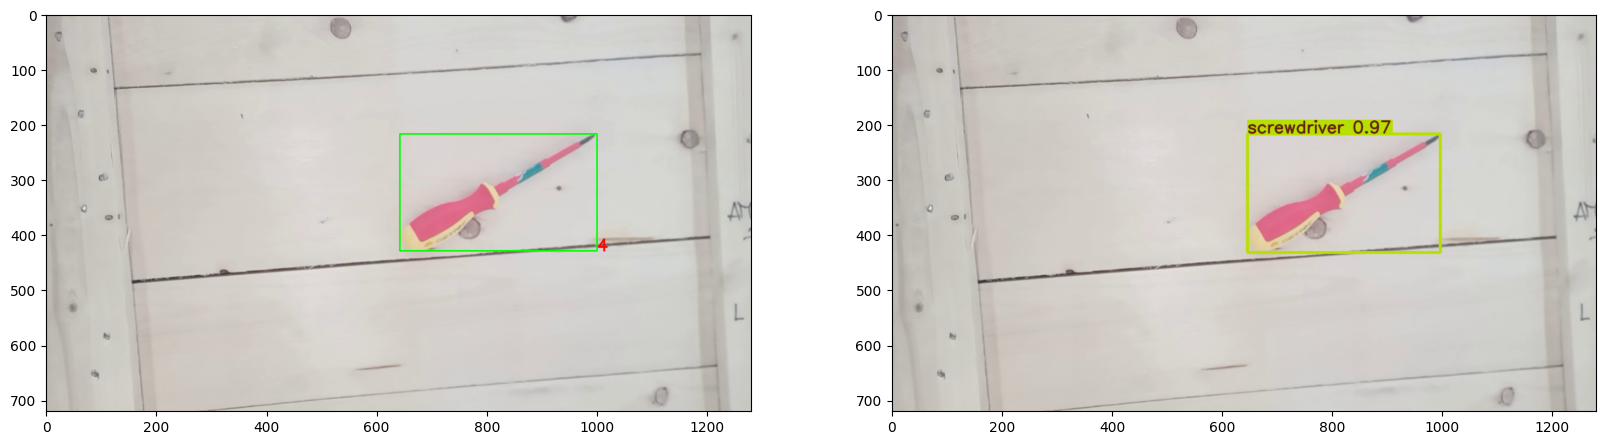


